# EDA PROJECT-1

## TRENDS SALES DATA

### IMPORTING FILES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Loading data files here to understand data format and problems in data , so that we can find a more efficient solution to help company grow faster and steadily.

In [2]:
Customers=pd.read_csv('messy_customers.csv')
Order_items=pd.read_csv('messy_order_items.csv')
Orders=pd.read_csv('messy_orders.csv')
Products=pd.read_csv('messy_products.csv')

In [3]:
Customers

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


In [4]:
Order_items

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [5]:
Orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [6]:
Products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


### 1) UNDERSTANDING DATA / PROBLEMS

In [7]:
Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    520 non-null    object
 1   customer_name  492 non-null    object
 2   city           479 non-null    object
 3   signup_date    520 non-null    object
dtypes: object(4)
memory usage: 16.4+ KB


In [8]:
Customers.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0133,Customer_466,Hyderabad,2023-06-15
freq,2,2,54,4


In [9]:
Customers[Customers.duplicated(keep=False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


In [10]:
Customers.duplicated().sum()

20

In [11]:
Order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   object 
 2   product_id     2050 non-null   object 
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.2+ KB


In [12]:
Order_items.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


In [13]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        1240 non-null   object
 1   customer_id     1240 non-null   object
 2   order_date      1240 non-null   object
 3   payment_method  1095 non-null   object
dtypes: object(4)
memory usage: 38.9+ KB


In [14]:
Orders.describe()

,order_id,customer_id,order_date,payment_method
count,1240,1240,1240,1095
unique,1200,448,815,7
top,O00966,C0218,05/03/2025,Credit Card
freq,2,10,5,171


In [15]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     object 
 1   product_name  90 non-null     object 
 2   category      90 non-null     object 
 3   base_price    33 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.9+ KB


In [16]:
Products.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


### 2) PRE-PROCESSING DATA

##### Deleting the duplicate rows from the data to make data more understandable, also correcting the date format in Customers and Orders table here.

In [17]:
Customers.drop_duplicates(inplace=True)

In [18]:
Order_items.drop_duplicates(inplace=True)

In [19]:
Orders.drop_duplicates(inplace=True)

In [20]:
Products.drop_duplicates(inplace=True)

In [21]:
Customers['signup_date'] = pd.to_datetime(Customers['signup_date'])

In [22]:
Orders['order_date'] = pd.to_datetime(Orders['order_date'],format="mixed")

### 3) HANDLING INCONSISTANT DATA

##### Making data consistent by replace the inconsistant values with a specific correct value.

In [23]:
Customers['city'] = Customers['city'].str.title()

In [24]:
Customers['city'] = Customers['city'].replace({'Bangalore':'Bengaluru'}).copy()

In [25]:
Orders['payment_method'] = Orders['payment_method'].str.title()
Orders['payment_method'] = Orders['payment_method'].replace({"Cash On Delivery":"Cash"})

In [26]:
Products['category'] = Products['category'].str.title()
Products['category'] = Products['category'].replace({"Smart Phone":"Smartphone","Accessories":"Accessory"}).copy()

In [27]:
Products['category'].unique()

array(['Tablet', 'Smartphone', 'Accessory', 'Laptop'], dtype=object)

### 4) HANDLING MISSING VALUES

##### Replacing the null values with suitable values for city & payment method column we used forward fill (ffill()) method, and for quantity & unit price column we used the mean value of their own columns to replace null values.

In [28]:
Customers['city'] = Customers['city'].bfill().copy()

In [29]:
Customers.isnull().sum()

customer_id       0
customer_name    28
city              0
signup_date       0
dtype: int64

In [30]:
Order_items['unit_price'] = Order_items['unit_price'].fillna(Order_items['product_id'].map(Products.set_index("product_id")['base_price']))

In [31]:
Order_items.fillna({"quantity":Order_items['quantity'].mean(),"unit_price":Order_items['unit_price'].mean()},inplace=True)
Order_items['quantity'] = Order_items['quantity'].astype(int)

In [32]:
Order_items.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
dtype: int64

In [33]:
Orders['payment_method'] = Orders['payment_method'].ffill()

In [34]:
Orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
payment_method    0
dtype: int64

In [35]:
Products.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

### 5) MERGING DATA

##### Here we merged the multiple tables by creating relationship between different tables, this step will make data more efficient for data analysis and visualization.

In [36]:
first = Customers.merge(Orders, on="customer_id", how="outer")

In [37]:
first

,customer_id,customer_name,city,signup_date,order_id,order_date,payment_method
0,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card
1,C0001,Customer_1,Delhi,2024-02-09,O00541,2024-10-19,Upi
2,C0001,Customer_1,Delhi,2024-02-09,O00675,2025-03-12,Upi
3,C0001,Customer_1,Delhi,2024-02-09,O00782,2024-01-20,Upi
4,C0001,Customer_1,Delhi,2024-02-09,O00987,2025-03-17,Cash
...,...,...,...,...,...,...,...
1247,C0498,Customer_498,Mumbai,2023-06-13,O00489,2025-11-01,Upi
1248,C0498,Customer_498,Mumbai,2023-06-13,O00789,2024-10-14,Upi
1249,C0498,Customer_498,Mumbai,2023-06-13,O01049,2024-08-30,Debit Card
1250,C0499,Customer_499,Delhi,2023-01-13,NaN,NaT,NaN


In [38]:
second = Order_items.merge(Products, on="product_id", how="outer")

In [39]:
second

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0
...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0


In [40]:
df = first.merge(second, on="order_id", how="inner")

In [41]:
df

,customer_id,customer_name,city,signup_date,order_id,order_date,payment_method,order_item_id,product_id,quantity,unit_price,product_name,category,base_price
0,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,1876,P006,2,45038.245702,Laptop Bag,Tablet,NaN
1,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,719,P029,4,45038.245702,Samsung Galaxy,Accessory,NaN
2,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,124,P033,2,47453.000000,Wireless Mouse,Laptop,47453.0
3,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,1206,P060,0,28975.000000,USB Hub,Laptop,NaN
4,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,397,P064,3,81129.000000,Lenovo IdeaPad,Accessory,81129.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C0498,Customer_498,Mumbai,2023-06-13,O00489,2025-11-01,Upi,1224,P076,3,30154.000000,Wireless Mouse,Accessory,15249.0
1996,C0498,Customer_498,Mumbai,2023-06-13,O00789,2024-10-14,Upi,53,P028,4,41806.000000,Samsung Galaxy,Tablet,NaN
1997,C0498,Customer_498,Mumbai,2023-06-13,O01049,2024-08-30,Debit Card,256,P042,1,80536.000000,HP Pavilion,Laptop,NaN
1998,C0498,Customer_498,Mumbai,2023-06-13,O01049,2024-08-30,Debit Card,1297,P064,0,35441.000000,Lenovo IdeaPad,Accessory,81129.0


### 6) TRANSFORMING / FEATURING DATA

##### Here more columns/data will be generated to find more meaningfull insights from data.
##### Created Amount column by doing product between quantity and unit price column to find total amount of particular order.
##### Created Year & Months column to find yearsly & monthly sales trends.

In [42]:
df['Amount'] = df['quantity']*df['unit_price'].astype(int)

In [43]:
df['Year'] = df['order_date'].dt.year
df['Months'] = df['order_date'].dt.month_name()

In [44]:
df

,customer_id,customer_name,city,signup_date,order_id,order_date,payment_method,order_item_id,product_id,quantity,unit_price,product_name,category,base_price,Amount,Year,Months
0,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,1876,P006,2,45038.245702,Laptop Bag,Tablet,NaN,90076,2024,February
1,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,719,P029,4,45038.245702,Samsung Galaxy,Accessory,NaN,180152,2024,February
2,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,124,P033,2,47453.000000,Wireless Mouse,Laptop,47453.0,94906,2024,February
3,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,1206,P060,0,28975.000000,USB Hub,Laptop,NaN,0,2024,February
4,C0001,Customer_1,Delhi,2024-02-09,O00309,2024-02-27,Debit Card,397,P064,3,81129.000000,Lenovo IdeaPad,Accessory,81129.0,243387,2024,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C0498,Customer_498,Mumbai,2023-06-13,O00489,2025-11-01,Upi,1224,P076,3,30154.000000,Wireless Mouse,Accessory,15249.0,90462,2025,November
1996,C0498,Customer_498,Mumbai,2023-06-13,O00789,2024-10-14,Upi,53,P028,4,41806.000000,Samsung Galaxy,Tablet,NaN,167224,2024,October
1997,C0498,Customer_498,Mumbai,2023-06-13,O01049,2024-08-30,Debit Card,256,P042,1,80536.000000,HP Pavilion,Laptop,NaN,80536,2024,August
1998,C0498,Customer_498,Mumbai,2023-06-13,O01049,2024-08-30,Debit Card,1297,P064,0,35441.000000,Lenovo IdeaPad,Accessory,81129.0,0,2024,August


### 7) EXPLORING DATA & VISUALIZATION

##### Here used graphs & charts to visualise & exploring the data.

In [45]:
Total_Revenue = df['Amount'].sum()
print(Total_Revenue)

165022905


##### From Months and Amount column from data we find the monthly sales trends, and visualise it by line chart.

In [46]:
monthly_sales = df.groupby('Months')['Amount'].sum()
print(monthly_sales.sort_values(ascending=False))

Months
January      22295973
April        21569540
March        20284390
February     17330191
May          14990941
June         11699701
December     10593742
July          9962410
October       9663555
November      9550609
September     8952450
August        8129403
Name: Amount, dtype: int32


Text(0, 0.5, 'Revenue')

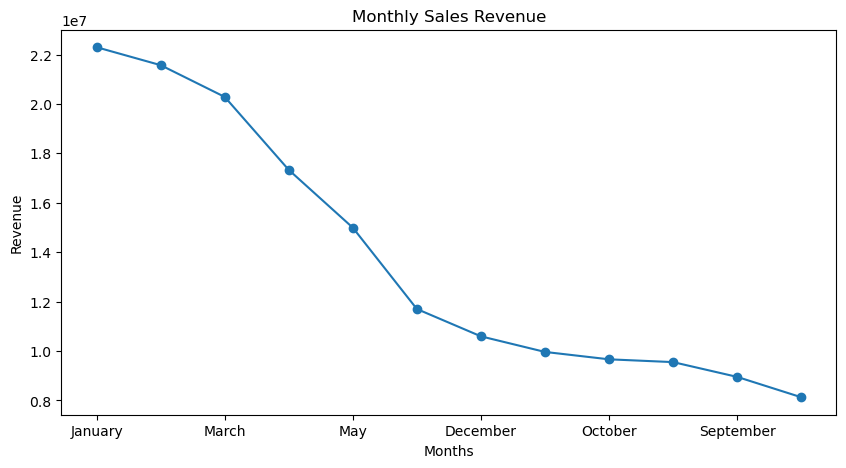

In [47]:
plt.figure(figsize=(10,5))
monthly_sales.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('Monthly Sales Revenue')
plt.xlabel('Months')
plt.ylabel('Revenue')

##### From Year and Amount column from data we find the yearly sales trends, and visualise it by bar graph.

In [48]:
yearly_sales = df.groupby('Year')['Amount'].sum()
yearly_sales_trend = pd.DataFrame(yearly_sales.sort_values(ascending = False))
yearly_sales_trend

,Amount
Year,
2024,120871466
2025,44151439


Text(0, 0.5, 'Revenue')

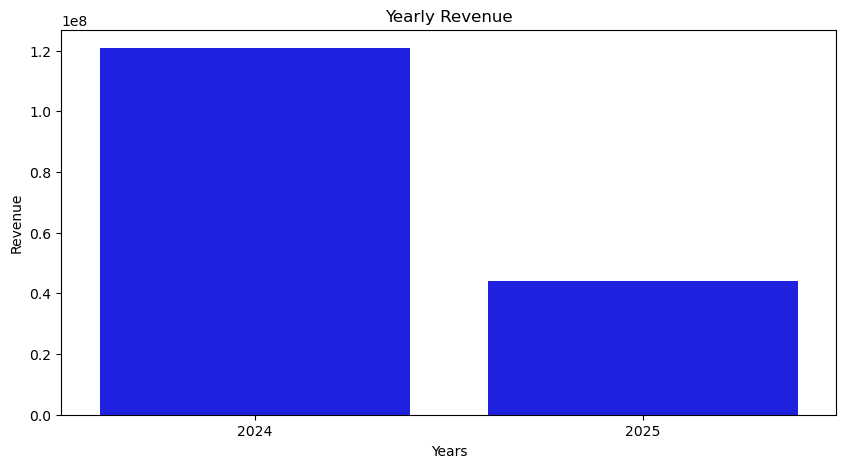

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(x='Year',y='Amount',data=yearly_sales_trend, color='blue')
plt.title('Yearly Revenue')
plt.xlabel('Years')
plt.ylabel('Revenue')

##### From product_name and Amount column from data we find the Product-wise revenue, and visualise it by bar graph.

In [50]:
Top_product = df.groupby('product_name')['Amount'].sum()
Top_5_product = pd.DataFrame(Top_product.sort_values(ascending=False).head())
Top_5_product

,Amount
product_name,
Dell Inspiron,17443401
Laptop Bag,17389619
Wireless Mouse,16556954
Xiaomi Redmi,15597322
Samsung Tab,13736694


Text(0, 0.5, 'Revenue')

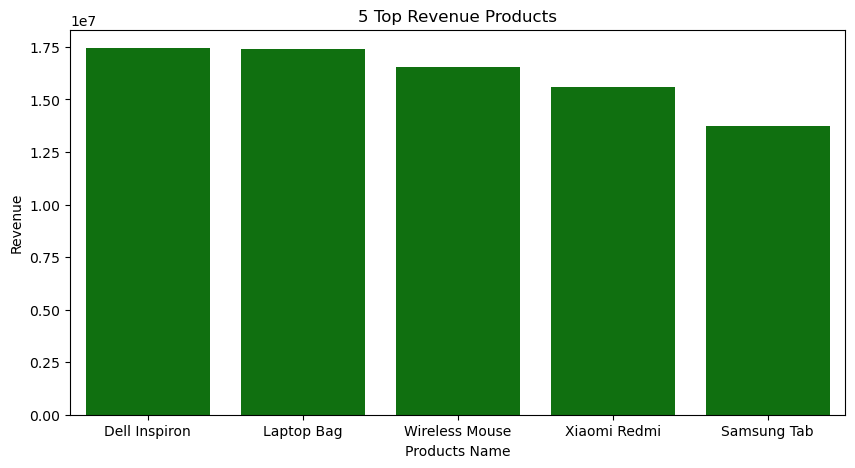

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(x='product_name',y='Amount',data=Top_5_product,color='green')
plt.title('5 Top Revenue Products')
plt.xlabel('Products Name')
plt.ylabel('Revenue')

##### From product_name and quantity column from data we find the Product-wise quanitity sold, and visualise it by bar graph.

In [52]:
Popular_products = df.groupby('product_name')['quantity'].sum()
Popular_5_products = pd.DataFrame(Popular_products.sort_values(ascending=False).head())
Popular_5_products

,quantity
product_name,
Wireless Mouse,378
Dell Inspiron,361
Laptop Bag,354
Xiaomi Redmi,345
Samsung Tab,292


Text(0, 0.5, 'Revenue')

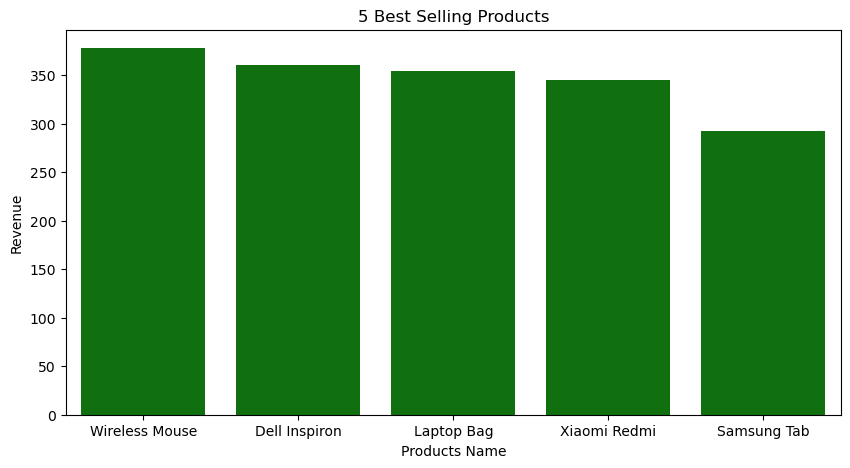

In [53]:
plt.figure(figsize=(10,5))
sns.barplot(x='product_name',y='quantity',data=Popular_5_products, color='green')
plt.title('5 Best Selling Products')
plt.xlabel('Products Name')
plt.ylabel('Revenue')

##### From category and Amount column from data we find the Category-wise revenue, and visualise it by bar graph.

In [54]:
Top_category = df.groupby('category')['Amount'].sum()
Top_5_categories = pd.DataFrame(Top_category.sort_values(ascending=False))
Top_5_categories

,Amount
category,
Smartphone,53880026
Accessory,41561172
Tablet,38008091
Laptop,31573616


Text(0, 0.5, 'Revenue')

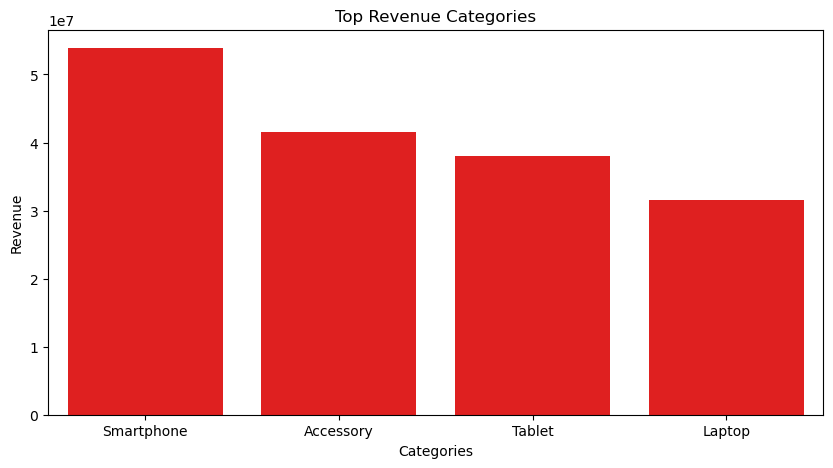

In [55]:
plt.figure(figsize=(10,5))
sns.barplot(x='category',y='Amount',data=Top_5_categories,color='Red')
plt.title('Top Revenue Categories')
plt.xlabel('Categories')
plt.ylabel('Revenue')

##### From category and quantity column from data we find the Category-wise quantity sold, and visualise it by bar graph.

In [56]:
Popular_category = df.groupby('category')['quantity'].sum()
popular_5_categories = pd.DataFrame(Popular_category.sort_values(ascending=False))
popular_5_categories

,quantity
category,
Smartphone,1187
Accessory,938
Tablet,852
Laptop,708


Text(0, 0.5, 'Quantities')

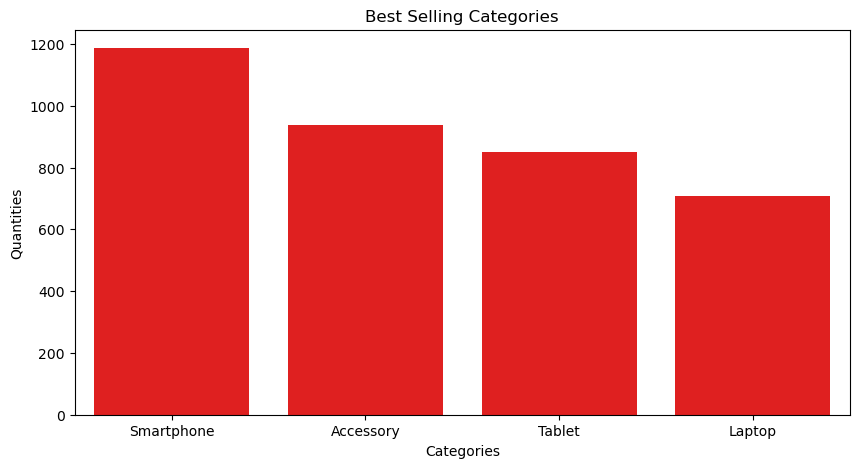

In [57]:
plt.figure(figsize=(10,5))
sns.barplot(x='category',y='quantity',data=popular_5_categories, color='red')
plt.title('Best Selling Categories')
plt.xlabel('Categories')
plt.ylabel('Quantities')

##### From city and Amount column from data we find the City-wise revenue, and visualise it by bar graph.

In [58]:
Top_city = df.groupby('city')['Amount'].sum()
Top_5_cities = pd.DataFrame(Top_city.sort_values(ascending=False).head())
Top_5_cities

,Amount
city,
Delhi,49714050
Mumbai,27276277
Hyderabad,23631778
Bengaluru,23559783
Pune,17009825


Text(0, 0.5, 'Revenue')

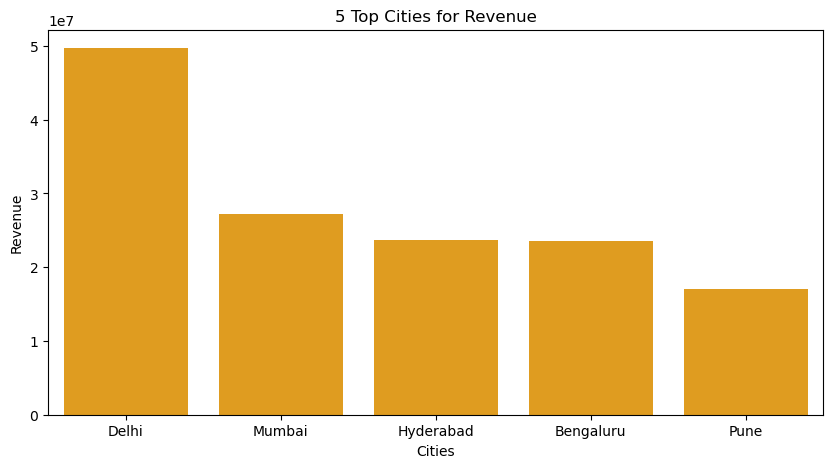

In [59]:
plt.figure(figsize=(10,5))
sns.barplot(x='city',y='Amount',data=Top_5_cities,color='Orange')
plt.title('5 Top Cities for Revenue')
plt.xlabel('Cities')
plt.ylabel('Revenue')

##### From city and Amount column from data we find the City-wise quantity sold, and visualise it by bar graph.

In [60]:
Popular_city = df.groupby('city')['quantity'].sum()
popular_5_cities = pd.DataFrame(Popular_city.sort_values(ascending=False).head())
popular_5_cities

,quantity
city,
Delhi,1100
Mumbai,638
Bengaluru,550
Hyderabad,512
Pune,376


Text(0, 0.5, 'Quantities')

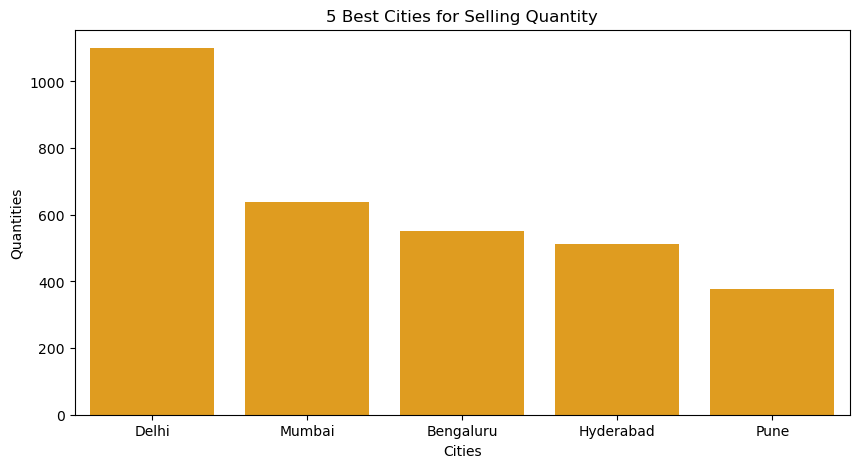

In [61]:
plt.figure(figsize=(10,5))
sns.barplot(x='city',y='quantity',data=popular_5_cities, color='orange')
plt.title('5 Best Cities for Selling Quantity')
plt.xlabel('Cities')
plt.ylabel('Quantities')

##### From payment_method and Amount column from data we find the Payment_method-wise revenue, and visualise it by bar graph.

In [62]:
Top_method = df.groupby('payment_method')['Amount'].sum()
Top_5_methods = pd.DataFrame(Top_method.sort_values(ascending=False))
Top_5_methods

,Amount
payment_method,
Cash,49578400
Upi,47240020
Credit Card,46314739
Debit Card,21889746


Text(0, 0.5, 'Revenue')

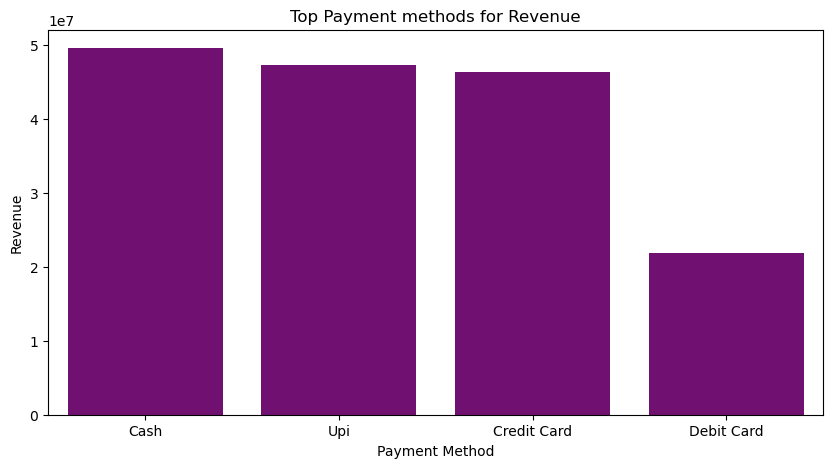

In [63]:
plt.figure(figsize=(10,5))
sns.barplot(x='payment_method',y='Amount',data=Top_5_methods,color='purple')
plt.title('Top Payment methods for Revenue')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')

##### From payment_method and quantity column from data we find the Payment_method-wise quantity sold, and visualise it by bar graph.

In [64]:
Popular_method = df.groupby('payment_method')['quantity'].sum()
popular_5_methods = pd.DataFrame(Popular_method.sort_values(ascending=False))
popular_5_methods

,quantity
payment_method,
Cash,1083
Credit Card,1066
Upi,1035
Debit Card,501


Text(0, 0.5, 'Quantities')

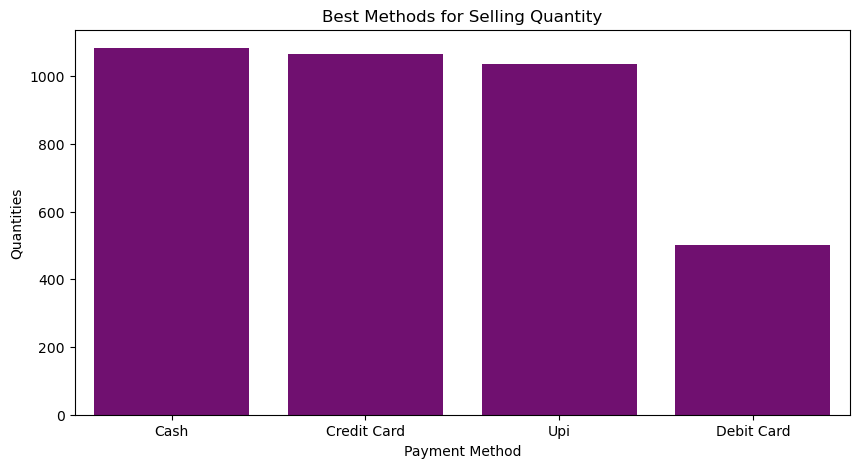

In [65]:
plt.figure(figsize=(10,5))
sns.barplot(x='payment_method',y='quantity',data=popular_5_methods, color='purple')
plt.title('Best Methods for Selling Quantity')
plt.xlabel('Payment Method')
plt.ylabel('Quantities')

##### From customer_name and Amount column from data we find the Customer-wise revenue, and visualise it by bar graph.

In [66]:
Top_customer = df.groupby('customer_name')['Amount'].sum()
Top_5_customers = pd.DataFrame(Top_customer.sort_values(ascending=False).head(10))
Top_5_customers

,Amount
customer_name,
Customer_218,1598033
Customer_142,1432298
Customer_474,1376599
Customer_233,1251787
Customer_281,1246648
Customer_454,1221913
Customer_187,1187860
Customer_33,1184263
Customer_137,1142205


Text(0, 0.5, 'Revenue')

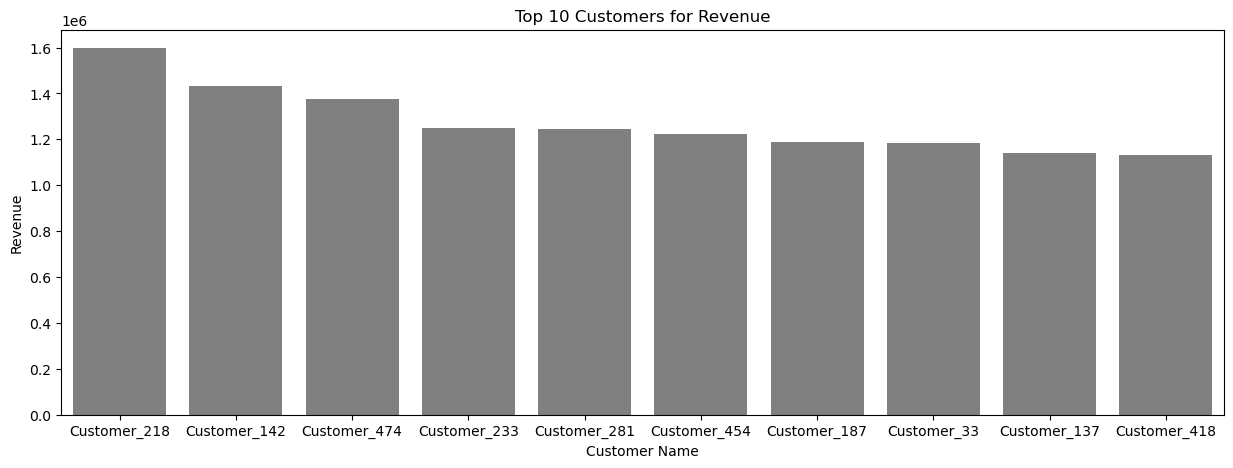

In [67]:
plt.figure(figsize=(15,5))
sns.barplot(x='customer_name',y='Amount',data=Top_5_customers,color='grey')
plt.title('Top 10 Customers for Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Revenue')

##### From customer_name and quantity column from data we find the Customer-wise quantity sold, and visualise it by bar graph.

In [68]:
Popular_customer = df.groupby('customer_name')['quantity'].sum()
popular_5_customers = pd.DataFrame(Popular_customer.sort_values(ascending=False).head(10))
popular_5_customers

,quantity
customer_name,
Customer_142,32
Customer_218,32
Customer_339,30
Customer_454,29
Customer_474,28
Customer_439,26
Customer_233,26
Customer_281,25
Customer_180,24


Text(0, 0.5, 'Quantities')

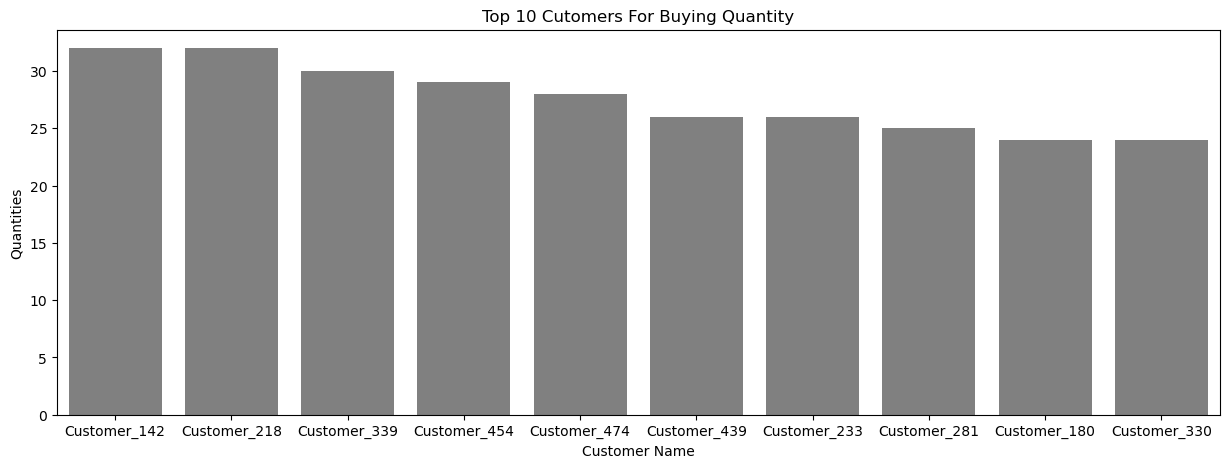

In [69]:
plt.figure(figsize=(15,5))
sns.barplot(x='customer_name',y='quantity',data=popular_5_customers, color='grey')
plt.title('Top 10 Cutomers For Buying Quantity')
plt.xlabel('Customer Name')
plt.ylabel('Quantities')

Text(0.5, 1.0, 'Correlation')

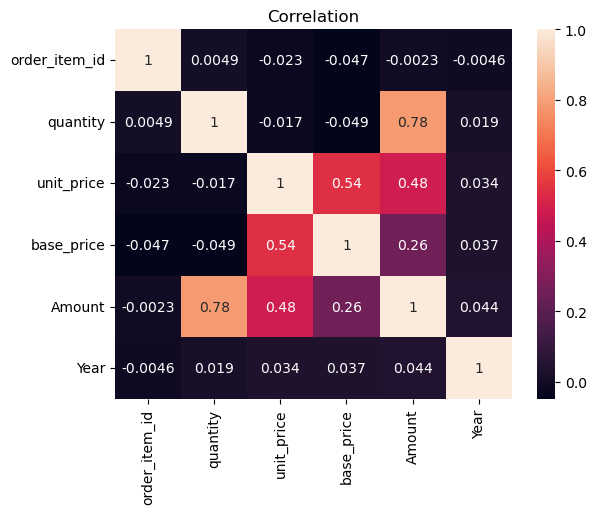

In [71]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

### 8) FINAL INSIGHTS

##### * Company has highest sales revenue in 2024 year and in January month.
##### * Top revenue products are Dell Inspiron and Laptop Bags, but Wireless Mouse sold more in quantity.
##### * Best Category for sales and revenue is Smartphone.
##### * Delhi is the top most city for quantity sold and revenue.
##### * Mostly customers used Cash payment method for product purchase.
##### * Customer_218 purchased highest quantity and also paid highest to the company.

#### CONCLUSION

##### *Dell Inspiron and Laptop Bags are highest revenue and Wireless Mouse is best selling product in Smartphone category in Delhi, where customers mostly used Cash Payment method to purchase our products and customer number 218 buys more number of products than other customers.